In [57]:
import numpy as np
class Logistic_Regression():

  def __init__(self, Learning_rate, No_of_iterations):
    self.Learning_rate = Learning_rate
    self.No_of_iterations = No_of_iterations


  def fit(self, X, Y):
    self.m, self.n = X.shape

    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

    for i in range(self.No_of_iterations):
      self.update_weights()


  def update_weights(self):
    Y_hat = 1 / (1 + np.exp(-(self.X.dot(self.w) + self.b)))

    dw = (1 / self.m) * self.X.T.dot(Y_hat - self.Y)
    db = (1 / self.m) * np.sum(Y_hat - self.Y)

    self.w = self.w - self.Learning_rate * dw
    self.b = self.b - self.Learning_rate * db

  def predict(self, X):
    Y_pred = 1 / (1 + np.exp(-(X.dot(self.w) + self.b)))
    Y_pred = np.where(Y_pred > 0.5, 1, 0)
    return Y_pred

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import Logistic_Regression_model as LR

In [59]:
diabetes_data = pd.read_csv('/content/diabetes.csv')

In [60]:
print(diabetes_data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [61]:
print(diabetes_data.tail())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
763                     0.171   63        0  
764                     0.340   27        0  
765                     0.245   30        0  
766                     0.349   47        1  
767                     0.315   23        0  


In [62]:
print(diabetes_data.shape)

(768, 9)


In [63]:
print(diabetes_data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [64]:
features = diabetes_data.iloc[:, :-1]

**0 -> Non diabetic**

**1 -> Diabetic**

In [65]:
scaler = StandardScaler()

In [66]:
scaler.fit(features)

StandardScaler()

In [67]:
standarides_data = scaler.transform(features)

In [68]:
X = standarides_data
Y = diabetes_data['Outcome']

In [69]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

In [70]:
model = LR.Logistic_Regression(Learning_rate=0.01, No_of_iterations=1000)

In [71]:
model.fit(X, Y)

In [72]:
X_train_predicted = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_predicted)
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.7703583061889251


In [73]:
X_test_predicted = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_predicted)
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.7662337662337663


confusion_matrix : 
 [[96 13]
 [23 22]]


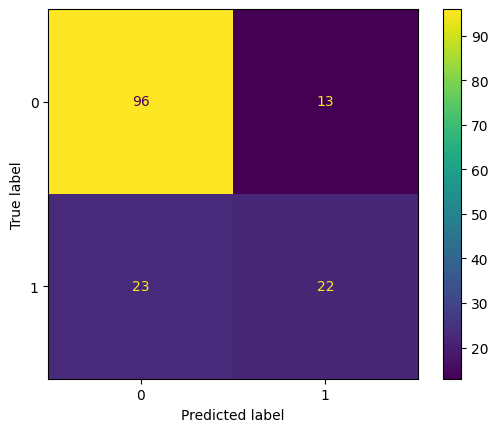

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, X_test_predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
print("confusion_matrix : \n", cm)
disp.plot()